# Regressão Linear com PyTorch

## Objetivos

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()

## Importação dos pacotes

In [176]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

torch.manual_seed(1234)

## Leitura dos dados

In [177]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [178]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [179]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [180]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)

## Criação do modelo da rede

In [181]:
model = torch.nn.Linear(2, 1, bias=False) #essa é a forma explícita (manual)
#model = torch.nn.Linear(1, 1) #por padrão, o bias é True. Utilizando dessa forma, o shape do x_train seria de 1 coluna apenas. Não precisa mais do x_train_bias, basta usar o x_train

### Verificando a inicialização dos parâmetros

In [182]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight.data

/tmp/ipykernel_1467/1486225639.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


tensor([[-0.0480, -0.0267]])

### Testando o predict da rede

In [183]:
model(Variable(torch.ones((5,2))))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

In [184]:
model(x_train_bias) #testando a rede com o bias

tensor([[-0.0747],
        [-0.0671],
        [-0.0734],
        [-0.0557],
        [-0.0684],
        [-0.0582],
        [-0.0658],
        [-0.0480],
        [-0.0696],
        [-0.0518],
        [-0.0493],
        [-0.0607],
        [-0.0620],
        [-0.0633],
        [-0.0569],
        [-0.0709],
        [-0.0569],
        [-0.0595],
        [-0.0645],
        [-0.0569],
        [-0.0607],
        [-0.0633],
        [-0.0658],
        [-0.0633],
        [-0.0671],
        [-0.0696],
        [-0.0722],
        [-0.0709],
        [-0.0620],
        [-0.0582],
        [-0.0557],
        [-0.0557],
        [-0.0595],
        [-0.0620],
        [-0.0544],
        [-0.0620],
        [-0.0709],
        [-0.0658],
        [-0.0569],
        [-0.0557],
        [-0.0557],
        [-0.0633],
        [-0.0595],
        [-0.0493],
        [-0.0569],
        [-0.0582],
        [-0.0582],
        [-0.0645],
        [-0.0506],
        [-0.0582]], grad_fn=<MmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [185]:
criterion = nn.MSELoss() #Perda/Loss (função de perda)
optimizer = optim.SGD(model.parameters(), lr=0.3) # Gradiente Descendente (obs: lr = learning rate)

### Laço de treinamento

In [186]:
num_epochs = 120
w0_list = []
w1_list = []

for epoch in range(num_epochs):
    inputs = x_train_bias
    target = y_train

    # forward - predict
    out = model(inputs)

    w0_list.append(model.weight.data[0][0].item())
    w1_list.append(model.weight.data[0][1].item())

    #loss cálculo da função de perda
    loss = criterion(out, target) #out é o y_pred

    # backward e otimizador
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.data) + ' -> w0: ' + str(model.weight.data[0][0].item()) + ' w1: ' + str(model.weight.data[0][1].item()))

Epoch[20/120], loss: 0.024990 -> w0: 0.38850119709968567 w1: 0.4408699572086334
Epoch[40/120], loss: 0.022381 -> w0: 0.3329596519470215 w1: 0.5481445789337158
Epoch[60/120], loss: 0.021554 -> w0: 0.3016778826713562 w1: 0.6085630655288696
Epoch[80/120], loss: 0.021291 -> w0: 0.2840595245361328 w1: 0.6425917148590088
Epoch[100/120], loss: 0.021208 -> w0: 0.27413663268089294 w1: 0.6617571115493774
Epoch[120/120], loss: 0.021182 -> w0: 0.2685479521751404 w1: 0.6725512742996216


## Avaliação

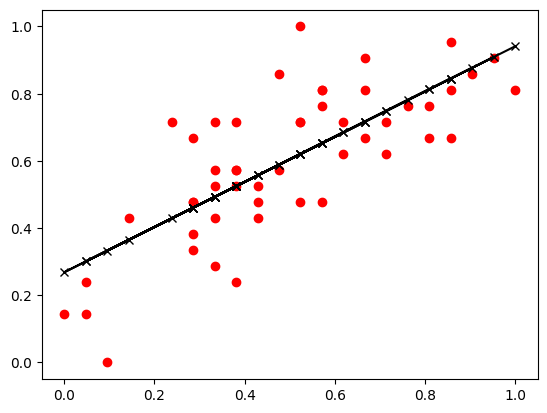

In [187]:
y_pred = model(x_train_bias)
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

# Exercícios

- 1) Calcule o valor da função de custo (MSE) depois da rede treinada, utilizando a
   função `criterion` utilizada no laço de treinamento.

In [188]:
model.weight

Parameter containing:
tensor([[0.2685, 0.6726]], requires_grad=True)

In [189]:
y_pred = model(Variable(x_train_bias))
loss = criterion(y_pred, Variable(y_train))
print(loss)

tensor(0.0212, grad_fn=<MseLossBackward0>)


<details>
<summary>Mostrar Resultado</summary>

```python
y_pred = model(Variable(x_train_bias))
loss = criterion(y_pred, Variable(y_train))
print(loss)
```

</details>

- 2) Faça igual o exercício do notebook anterior, de plotar um gráfico scatterplot para
   mostrar a evolução dos parâmetros durante o treinamento pelo gradiente descendente.

In [190]:
#calcular o peso ótimo
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
print(torch.t(w_opt))

tensor([[0.2613, 0.6865]])


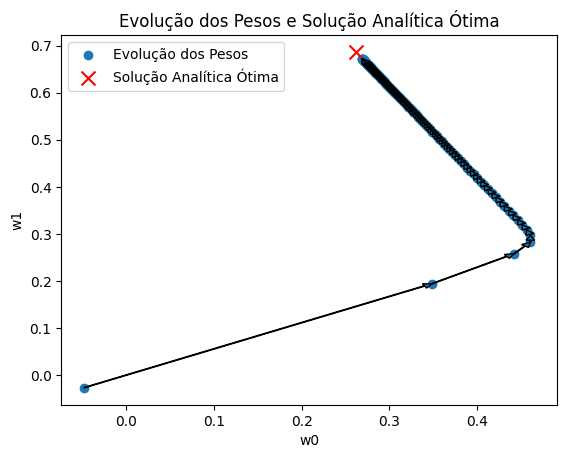

In [191]:
plt.scatter(w0_list,w1_list, label='Evolução dos Pesos')

# Adicionando o valor ótimo do parâmetro dado pela solução analítica
w_opt_w0 = w_opt[0]
w_opt_w1 = w_opt[1]
plt.scatter(w_opt_w0, w_opt_w1, marker='x', color='red', s=100, label='Solução Analítica Ótima')

w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1

plt.xlabel('w0')
plt.ylabel('w1')
plt.title('Evolução dos Pesos e Solução Analítica Ótima')
plt.legend()
plt.show()

<details>
<summary>Mostrar Resultado</summary>

```python
plt.scatter(w0_list,w1_list)
w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1
```

</details>

# Aprendizados

O modelo foi treinado com **120** épocas. Ao tentar treinar com uma quantidade menor de épocas (ex: **60**), mantendo o mesmo learning-rate de *"0.3"*, os pesos calculados ficaram muito distantes do peso ideal. Porém, alterando o lr para *"0.6"* e mantendo as **60** épocas, os resultados visuais foram bem próximos das configurações iniciais.